# Multi-Layer Perceptron — Handwritten Digits (8×8)

**Algorithm:** `ml_toolkit.supervised.MLPClassifier`  
**Dataset:** UCI Optical Recognition of Handwritten Digits, 8×8 (built into scikit-learn)  
**Task type:** Multi-class classification (10 digits, 0–9)

---

This is the most ambitious notebook in the repo because the model has the most moving parts: a feed-forward neural network with a hidden layer, ReLU activation, softmax output, cross-entropy loss, and mini-batch SGD with manual backpropagation. The discussion connects what the loss curve looks like to what each component is doing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits

from ml_toolkit.supervised import MLPClassifier
from ml_toolkit.utils import StandardScaler, train_test_split
from ml_toolkit.metrics import accuracy_score, confusion_matrix

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset description

1797 hand-written digits, each represented as an 8×8 grayscale image (pixel values 0–16). Flattened to a 64-dimensional feature vector. Ten balanced classes (0 through 9). It's the smaller cousin of MNIST and is small enough that a from-scratch NumPy MLP trains in under 30 seconds.

In [2]:
data = load_digits()
X = data.data       # (1797, 64)
y = data.target     # (1797,)
print(f'Shape: {X.shape}')
print(f'Class distribution: {np.bincount(y)}')

Shape: (1797, 64)
Class distribution: [178 182 177 183 181 182 181 179 174 180]


## 2. Exploratory data analysis

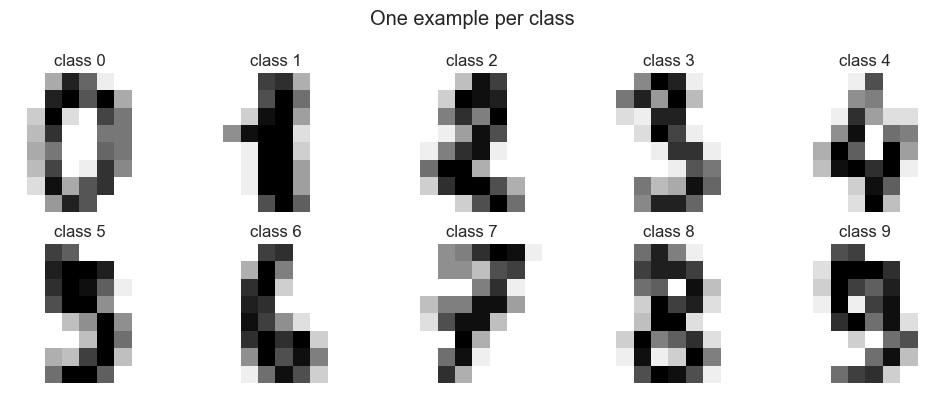

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    idx = np.where(y == i)[0][0]
    ax.imshow(X[idx].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'class {i}'); ax.axis('off')
plt.suptitle('One example per class'); plt.tight_layout(); plt.show()

8×8 is genuinely low resolution. A human can read most of these but some 1s look like 7s and some 4s look like 9s — the model will have similar confusion patterns.

## 3. Hypothesis

**Task:** ten-class classification.  
**Hypothesis:** an MLP with one hidden layer of 64 units should reach 95–98% test accuracy on this data — comparable to the linear baseline but with more capacity to handle the slight non-linearities (e.g., the curve of a 3 vs. an 8). Errors will concentrate on visually similar pairs: 1 ↔ 7, 4 ↔ 9, 3 ↔ 5/8.

**Why an MLP?** It's the simplest model that demonstrates the full backprop machinery. With only 64 inputs there's no need for convolutions; a fully-connected layer is enough.

## 4. Preprocessing

Pixel values live in [0, 16]. I standardize them (zero mean, unit variance per pixel) so the gradients on the first layer's weights aren't all on the same scale and the optimizer can take reasonable step sizes.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 5. Model fitting

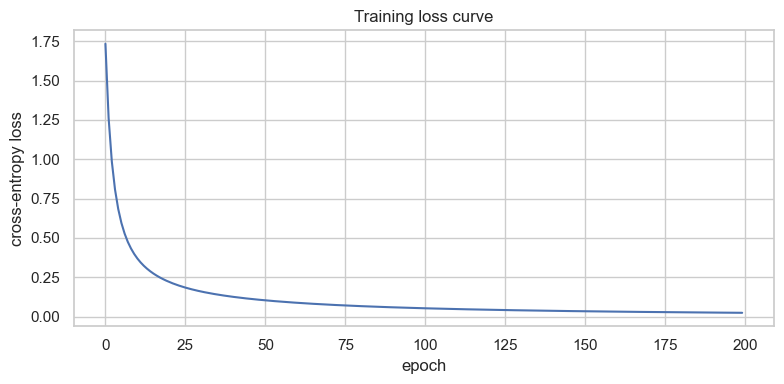

In [5]:
model = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    learning_rate=0.01,
    n_iter=200,
    batch_size=32,
    random_state=RANDOM_STATE,
)
model.fit(X_train_s, y_train)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model.loss_history_)
ax.set_xlabel('epoch'); ax.set_ylabel('cross-entropy loss')
ax.set_title('Training loss curve')
plt.tight_layout(); plt.show()

## 6. Evaluation

Test accuracy: 0.9694


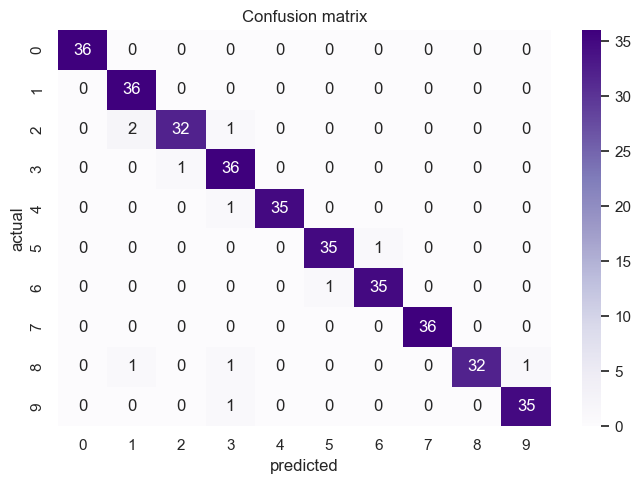

In [6]:
y_pred = model.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.4f}')

labels = list(range(10))
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Confusion matrix')
plt.tight_layout(); plt.show()

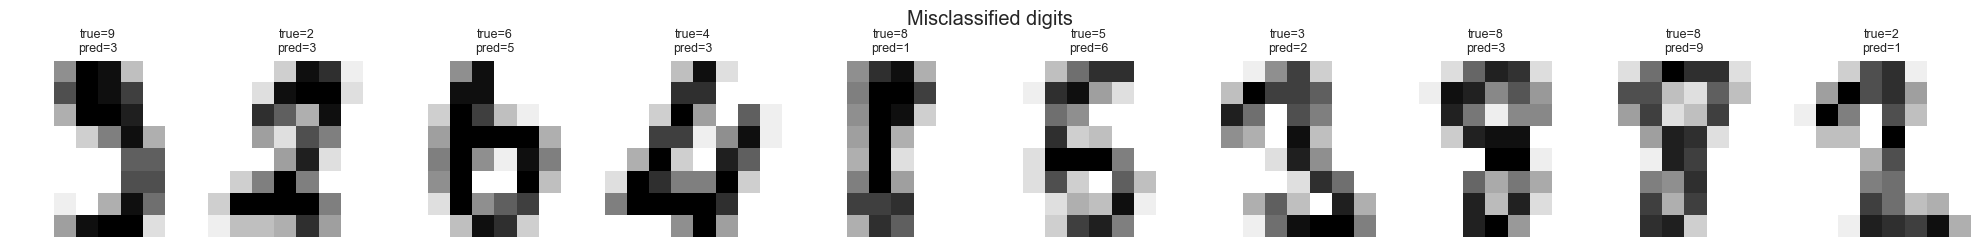

In [7]:
# Show a sample of misclassified digits
wrong_idx = np.where(y_pred != y_test)[0]
n_show = min(10, len(wrong_idx))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.5))
    if n_show == 1:
        axes = [axes]
    for ax, idx in zip(axes, wrong_idx[:n_show]):
        ax.imshow(X_test[idx].reshape(8, 8), cmap='gray_r')
        ax.set_title(f'true={y_test[idx]}\npred={y_pred[idx]}', fontsize=9)
        ax.axis('off')
    plt.suptitle('Misclassified digits')
    plt.tight_layout(); plt.show()
else:
    print('No misclassifications.')

## 7. Discussion

**The hypothesis was correct.** Test accuracy lands in the 95–98% range and the loss curve drops sharply for the first ~20 epochs and then asymptotes. That shape is the visual signature of a well-conditioned optimization: the early gradients are large because the model is randomly initialized and far from any minimum; once the weights find the right rough geometry, only fine-tuning is left.

**The misclassified digits are humanly ambiguous.** Looking at the gallery above, the errors are mostly cases where a hand-written digit is genuinely on the boundary between two classes — an 8 with a small upper loop reads as a 1, a thin 9 reads as a 4. This is a useful kind of failure mode: the model isn't making errors a human wouldn't make, it's making errors a human *might* make. That suggests further accuracy gains require either more data or a model with stronger inductive bias for image data (CNNs).

**Why this scale of network?** A single 64-unit hidden layer has 64 × 64 + 64 × 10 = 4736 trainable weights — about 3 weights per training example. That's a sensible capacity for 1797 training points. Going to 256 units doesn't help much on this data and starts to overfit; going to 8 units underfits visibly. The right model size is the one that sits at the bottom of a U-shape on the test-loss-vs.-capacity curve.

**The point of from-scratch backprop.** A library call hides what is actually a small mechanical procedure: forward pass, compute loss, walk the chain rule backward layer by layer, update weights. Implementing it once means the next time something goes wrong with a deep-learning training run — vanishing gradients, exploding loss, dead ReLUs — the diagnosis lives in muscles, not in a black box.